# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.train import train_model
from src.eval import plot_samples_grid
from src.schedule import ts_desc

from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import torch

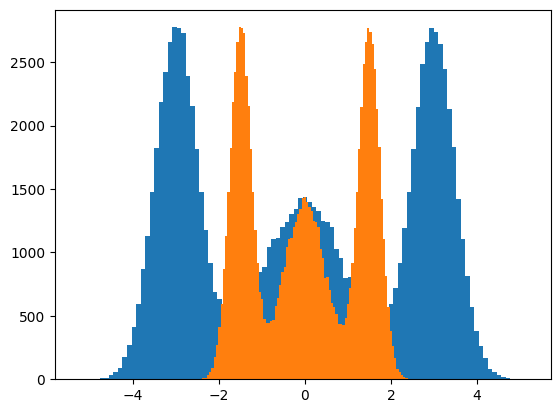

In [2]:
def generate_gaussian_mixture(n_samples, means, stds, device='cpu'):
	"""Generates mixture of gaussians according to inputted means and standard deviations"""
	means = torch.as_tensor(means, dtype=torch.float32)
	n_gaussians = len(means)
	
	if isinstance(stds, (int, float)):
		stds = torch.full((n_gaussians,), float(stds))
	else:
		stds = torch.as_tensor(stds, dtype=torch.float32)
		assert len(stds) == n_gaussians, f"stds length {len(stds)} != n_gaussians {n_gaussians}"
		
	component_ids = np.random.choice(n_gaussians, size=n_samples)
	samples = torch.zeros(n_samples, 1, device=device)
	
	for i in range(n_gaussians):
		mask = component_ids == i
		samples[mask] = torch.normal(
			mean=float(means[i]),
			std=float(stds[i]),
			size=(mask.sum(), 1)
		).to(device)
	
	return samples
samples = generate_gaussian_mixture(100_000, [-3.0, 0.0, 3.0], [0.5, 1.0, 0.5])
_ = plt.hist(samples, bins = 100)
_ = plt.hist(samples/np.sqrt(4), bins = 100)

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

Device:                  cuda
Figure rows will be: 	 method
Figure columns will be:  k

Running sampling with method = ULA and k = 4.0
Swaps within [1.  2.5 4. ]

time 99: x has standard deviation 1.00
time 99: x has standard deviation 1.00

time 99: x has standard deviation 1.00
time 99: x has standard deviation 1.00

time 99: x has standard deviation 1.00
time 99: x has standard deviation 1.00
Langevin step 0
time 99 chain 1.0: input to chain 1.1476699113845825
x hat has standard deviation 1.42
Langevin step 0
time 99 chain 2.5: input to chain 1.1436667442321777
x hat has standard deviation 1.42
Langevin step 0
time 99 chain 4.0: input to chain 1.1464906930923462
x hat has standard deviation 1.42


KeyboardInterrupt: 

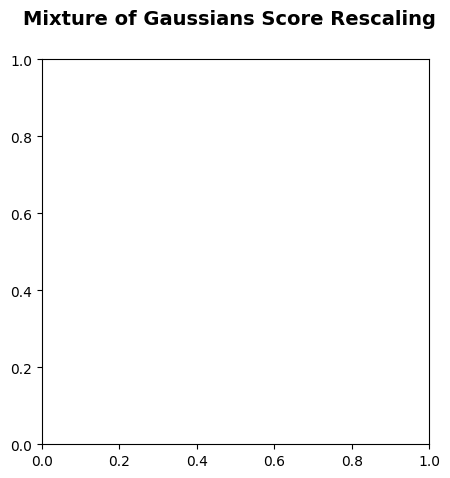

In [4]:
dataset_name = "composed"
methods = ["ULA"]
k = [4.0]
sigma = 0.5
step_scale = 1
n_langevin_steps = 4
filename = "testing_parallel"

samples, figures = plot_samples_grid(
	dataset_name=dataset_name, 
	method=methods, 
	k=k, 
	sigma=sigma, 
	step_scale=step_scale, 
	n_langevin_steps=n_langevin_steps, 
	x_limit = 10, save_dir="figures", filename=filename
)

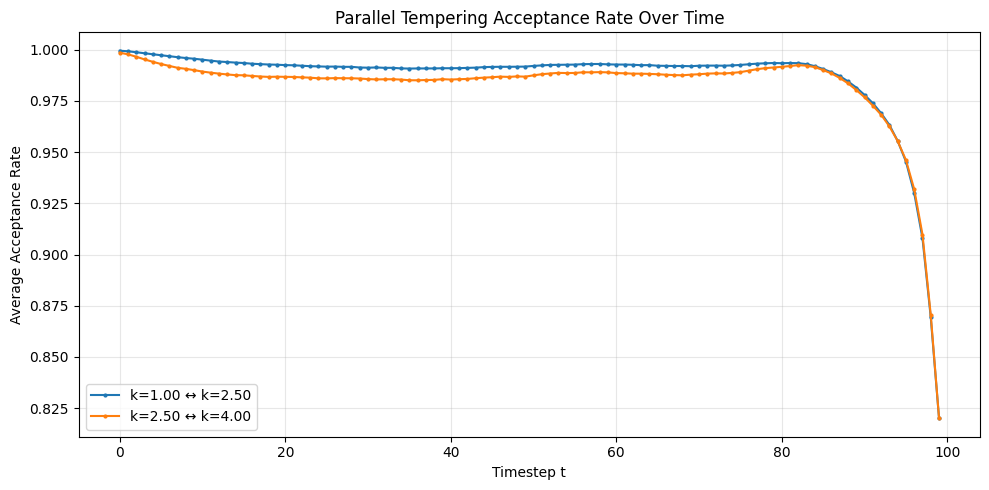

In [ ]:


def plot_acceptance_over_time(acceptance_ladder):

	fig, ax = plt.subplots(figsize=(10, 5))

	for (k_less, k_more), records in acceptance_ladder.items():
		# Group acceptance rates by timestep t
		by_time = defaultdict(list)
		for r in records:
			by_time[r["t"]].append(r["acceptance"].cpu().mean().item())

		# Average over langevin steps at each t
		ts = sorted(by_time.keys())
		ts_cpu = [item.cpu() for item in ts]

		avg_acceptance = [sum(by_time[t]) / len(by_time[t]) for t in ts]

		ax.plot(ts_cpu, avg_acceptance, label=f"k={k_less:.2f} ↔ k={k_more:.2f}", marker='o', markersize=2)

	ax.set_xlabel("Timestep t")
	ax.set_ylabel("Average Acceptance Rate")
	ax.set_title("Parallel Tempering Acceptance Rate Over Time")
	ax.legend()
	ax.grid(True, alpha=0.3)
	plt.tight_layout()
	plt.show()

	return fig

_ = plot_acceptance_over_time(figures)

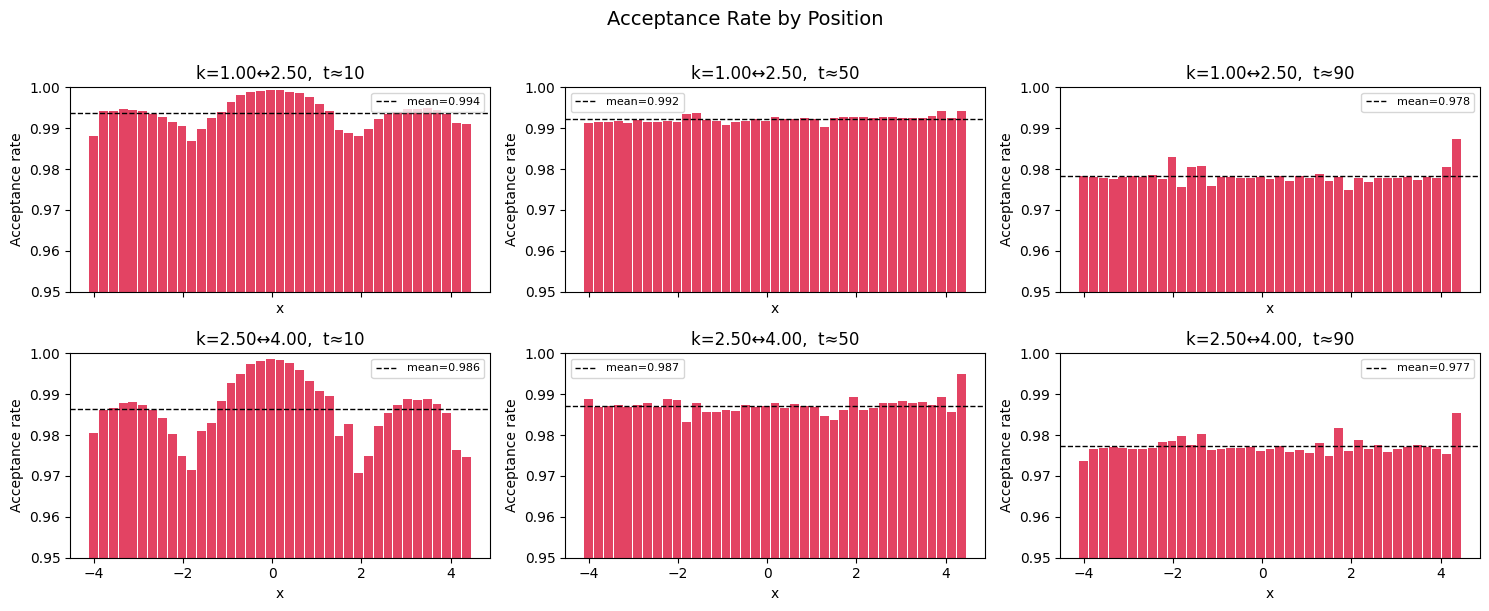

In [ ]:
def plot_acceptance_over_position(acceptance_ladder, x_final, timesteps_to_show=[10, 50, 90]):
    x_np = x_final.detach().cpu().numpy().flatten()
    
    bins = np.linspace(x_np.min(), x_np.max(), 40)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    n_pairs = len(acceptance_ladder)
    n_times = len(timesteps_to_show)
    
    fig, axes = plt.subplots(
        n_pairs, n_times,
        figsize=(5 * n_times, 3 * n_pairs),
        sharex=True
    )
    if n_pairs == 1:
        axes = axes[np.newaxis, :]
    if n_times == 1:
        axes = axes[:, np.newaxis]

    for row, ((k_less, k_more), records) in enumerate(acceptance_ladder.items()):
        by_time = defaultdict(list)
        for r in records:
            by_time[r["t"]].append(r["acceptance"].cpu())

        for col, t in enumerate(timesteps_to_show):
            ax = axes[row, col]

            closest_t = min(by_time.keys(), key=lambda t_: abs(t_ - t))
            stacked = torch.stack(by_time[closest_t], dim=0).float()  # (n_langevin, n_particles)
            per_particle_acceptance = stacked.mean(dim=0).numpy().flatten()

            bin_indices = np.digitize(x_np, bins) - 1
            bin_indices = np.clip(bin_indices, 0, len(bin_centers) - 1)

            bin_acceptance = np.full(len(bin_centers), np.nan)
            for b in range(len(bin_centers)):
                mask = bin_indices == b
                if mask.sum() > 0:
                    bin_acceptance[b] = per_particle_acceptance[mask].mean()

            valid = ~np.isnan(bin_acceptance)
            ax.bar(bin_centers[valid], bin_acceptance[valid],
                   width=bin_width * 0.9, color="crimson", alpha=0.8)
            
            mean_acc = np.nanmean(bin_acceptance)
            ax.axhline(mean_acc, color='black', linestyle='--', linewidth=1,
                       label=f"mean={mean_acc:.3f}")
            
            ax.set_ylim(0.95, 1)
            ax.set_ylabel("Acceptance rate")
            ax.set_xlabel("x")
            ax.set_title(f"k={k_less:.2f}↔{k_more:.2f},  t≈{closest_t}")
            ax.legend(fontsize=8)

    fig.suptitle("Acceptance Rate by Position", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    return fig

_ = plot_acceptance_over_position(figures, samples[(0,0)]["samples"])